In [25]:
import pandas as pd
import shap

from eda_package.data import DataManager
from eda_package.features import FeatureEngineer
from eda_package.preprocessor import PreprocessorManager
from eda_package.model import ModelManager
from eda_package.explainer import *

In [27]:
preprocessor_manager = PreprocessorManager()
preprocessor_manager.load()
X_train_preprocessed = preprocessor_manager.transform(X_train_fe)

In [28]:
df = data_manager.prepare_dataset()
X_train, X_test, y_train, y_test = data_manager.prepare_train_test_data()

In [29]:
model_manager = ModelManager()
model_manager.train(X_train_preprocessed, y_train)
#metrics = model_manager.evaluate(X_test_preprocessed, y_test)
model_manager.save()

In [30]:
data_manager = DataManager()
feature_engineer = FeatureEngineer()
preprocessor_manager = PreprocessorManager()
model_manager = ModelManager()
explainer_manager = ExplainerManager()

preprocessor_manager.load()
model_manager.load()

X_train, X_test, y_train, y_test = data_manager.prepare_train_test_data()

In [32]:
X_train_fe = feature_engineer.engineer_features(X_train.copy())
X_test_fe = feature_engineer.engineer_features(X_test.copy())

X_train_processed = preprocessor_manager.transform(X_train_fe)
X_test_processed = preprocessor_manager.transform(X_test_fe)

feature_names = preprocessor_manager.preprocessor.get_feature_names_out()

X_train_shap = explainer_manager.transform_to_shap_df(
    X_processed=X_train_processed,
    feature_names=feature_names,
    index=X_train.index,
)

X_test_shap = explainer_manager.transform_to_shap_df(
    X_processed=X_test_processed,
    feature_names=feature_names,
    index=X_test.index,
)

In [33]:
background = X_train_shap.iloc[:50]
explainer_manager.build_explainer(model_manager, background)

In [34]:
local_result = explainer_manager.explain_local(X_test_shap.iloc[:20], row_index=0)

grouped_local = local_result["grouped_local_shap"]
grouped_local.head(10)

PermutationExplainer explainer: 21it [00:13,  1.18it/s]                        


,feature_group,shap_value
26,room_type_mismatch,-0.170994
20,lead_time,-0.143781
5,arrival_date_year,-0.092519
13,country,-0.072489
2,agent,0.040038
30,total_of_special_requests,0.015344
16,deposit_type,-0.013773
6,assigned_room_type,0.013067
0,adr,0.007125
17,distribution_channel,-0.004872


In [35]:
higher_risk, lower_risk = explainer_manager.split_local_drivers(grouped_local, top_n=5)

print("Higher cancellation risk")
display(higher_risk)

print("Lower cancellation risk")
display(lower_risk)

Higher cancellation risk


,feature_group,shap_value
0,agent,0.040038
1,total_of_special_requests,0.015344
2,assigned_room_type,0.013067
3,adr,0.007125
4,special_requests_per_guest,0.004820


Lower cancellation risk


,feature_group,shap_value
0,room_type_mismatch,-0.170994
1,lead_time,-0.143781
2,arrival_date_year,-0.092519
3,country,-0.072489
4,deposit_type,-0.013773


In [36]:
global_result = explainer_manager.explain_global(X_test_shap.iloc[:20])

grouped_global = global_result["grouped_global_shap"]
grouped_global.head(15)

,feature_group,mean_abs_shap
13,country,0.178797
2,agent,0.085896
21,market_segment,0.063692
20,lead_time,0.056791
24,required_car_parking_spaces,0.046339
26,room_type_mismatch,0.044908
30,total_of_special_requests,0.044058
14,customer_type,0.034438
16,deposit_type,0.034226
5,arrival_date_year,0.029168


In [37]:
X_test_dates = X_test.copy()
X_test_dates["arrival_date"] = pd.to_datetime(
    X_test_dates["arrival_date_day_of_month"].astype(str)
    + " "
    + X_test_dates["arrival_date_month"].astype(str)
    + " "
    + X_test_dates["arrival_date_year"].astype(str),
    format="%d %B %Y",
    errors="coerce"
)

X_test_dates["arrival_date"].value_counts().head(10)

2017-04-13    51
2017-07-15    50
2017-07-31    48
2016-12-30    48
2017-04-29    48
2016-06-26    47
2017-05-05    44
2015-08-10    42
2017-08-07    42
2016-10-06    41
Name: arrival_date, dtype: int64

In [38]:
selected_date = "2017-07-15"

date_result = explainer_manager.explain_global_for_date(
    selected_date=selected_date,
    X_raw=X_test,
    data_manager=data_manager,
    feature_engineer=feature_engineer,
    preprocessor_manager=preprocessor_manager,
    min_rows=5,
)

print(f"Date: {selected_date}")
print(f"Number of bookings: {date_result['n_bookings']}")

if date_result["message"]:
    print(f"{date_result['message']}")

if date_result["grouped_global_shap"] is not None:
    display(date_result["grouped_global_shap"].head(15))

PermutationExplainer explainer: 51it [00:11,  1.66s/it]                        

Date: 2017-07-15
Number of bookings: 50


,feature_group,mean_abs_shap
13,country,0.193600
2,agent,0.114049
20,lead_time,0.078753
21,market_segment,0.071110
30,total_of_special_requests,0.050099
14,customer_type,0.042728
5,arrival_date_year,0.027247
27,special_requests_per_guest,0.026635
0,adr,0.026095
26,room_type_mismatch,0.025947


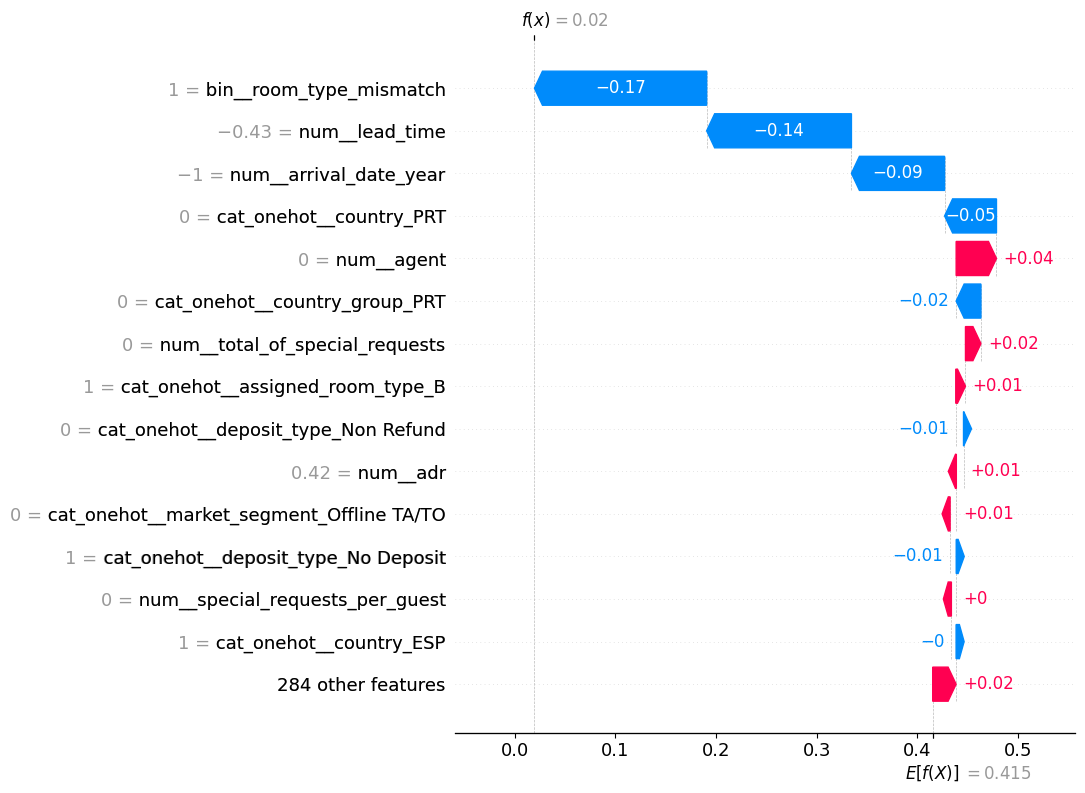

In [39]:
local_shap_values = local_result["shap_values"]
shap.plots.waterfall(local_shap_values[0], max_display=15)

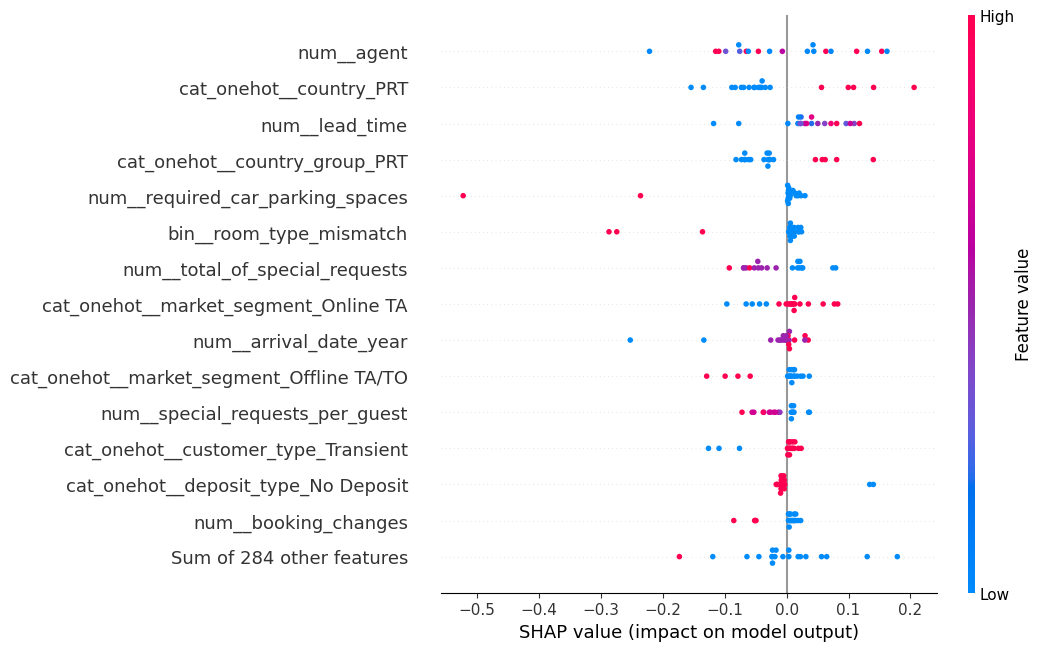

In [40]:
global_shap_values = global_result["shap_values"]
shap.plots.beeswarm(global_shap_values, max_display=15)